### 포징 데이터 캡쳐

In [16]:
import cv.pose_estimation_v3_local_video as cap

labels = [0, 1]
labels = [2, 3]
labels = [4, 5]
labels = [6, 7]
labels = [8, 9]


labels = [2, 4, 6] # F-Hook, F-Upper, F-Body
labels = [3, 5, 7] # B-Hook, B-Upper, B-Body
labels = [1, 2, 9] # Straight, F-Hook, Body-Straight
labels = [0, 4, 1, 9] # Jab, F-Upper, Straight, Body-Straight
labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # All Pose
labels = [4, 6] # F-Upper, F-Body
labels = [2, 4, 6] # Jab F-Hook, F-Upper, F-Body
labels = [0, 4, 1, 3] # Jab F-Upper, Straight, B-Hook
labels = [0, 2, 4] # Jab, F-Hook, F-Upper

trainset_path = 'dataset/pose/boxing_pose_world_coords.csv'
testset_path = 'dataset/pose/test_boxing_pose_world_coords.csv'
cap.run(
    testRun = False,
    chunk = 12,
    labelsToRun = labels,
    data_file_path = trainset_path,
)


[ WARN:0@933.983] global /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_11nitadzeg/croot/opencv-suite_1691620374638/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


label=0 value:Jab
NOSE: (x: -0.059884123504161835, y: -0.6427187919616699, z: -0.18696413934230804)
LEFT_EYE_INNER: (x: -0.0491863489151001, y: -0.6809755563735962, z: -0.17578497529029846)
LEFT_EYE: (x: -0.048658587038517, y: -0.6815226078033447, z: -0.17509394884109497)
LEFT_EYE_OUTER: (x: -0.0492580272257328, y: -0.6817164421081543, z: -0.17506463825702667)
RIGHT_EYE_INNER: (x: -0.08026012778282166, y: -0.6767060160636902, z: -0.16679109632968903)
RIGHT_EYE: (x: -0.07967855036258698, y: -0.6776131391525269, z: -0.1674812138080597)
RIGHT_EYE_OUTER: (x: -0.08006694912910461, y: -0.6789712905883789, z: -0.16640974581241608)
LEFT_EAR: (x: 0.023469291627407074, y: -0.6817781329154968, z: -0.08061788231134415)
RIGHT_EAR: (x: -0.11841557174921036, y: -0.6735460758209229, z: -0.053042713552713394)
MOUTH_LEFT: (x: -0.027062678709626198, y: -0.6251907348632812, z: -0.1512923687696457)
MOUTH_RIGHT: (x: -0.06854657083749771, y: -0.6207212805747986, z: -0.14323784410953522)
LEFT_SHOULDER: (x: 0.

### 훈련

relu layer unit 수를 20(10보다 큰값)으로 해야지 loss가 현격히 감소함
0.8~ 에서 0.5~ 로 변경됨

Newly creates in tf/models/boxing_pose_est_1728116186.keras
Epoch 1/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - categorical_accuracy: 0.1257 - loss: 2.3916 - val_categorical_accuracy: 0.1220 - val_loss: 2.3444
Epoch 2/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - categorical_accuracy: 0.1371 - loss: 2.2608 - val_categorical_accuracy: 0.1220 - val_loss: 2.2668
Epoch 3/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - categorical_accuracy: 0.1689 - loss: 2.1961 - val_categorical_accuracy: 0.1220 - val_loss: 2.2246
Epoch 4/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - categorical_accuracy: 0.2406 - loss: 2.1234 - val_categorical_accuracy: 0.2683 - val_loss: 2.1693
Epoch 5/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step - categorical_accuracy: 0.2357 - loss: 2.0858 - val_categorical_accuracy: 0.2195 - val_loss: 2.1296
Epoch 6/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - categorical_accuracy: 0.2991 - loss: 1.9707 - val_categorical_accuracy: 0.2439 - val_loss: 2.0869
Epoch 7/1000
37/37

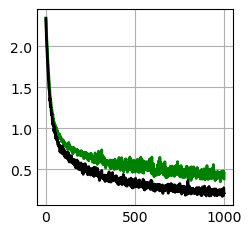

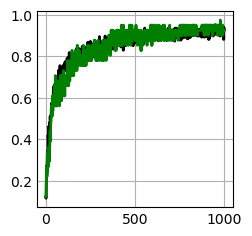

Restoring model weights from the end of the best epoch: 979.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 23, 3)          │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,835 (18.89 KB)

 Trainable params: 1,610 (6.29 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 3,222 (12.59 KB)

In [1]:
import tf.regression_train_csv as t
import tensorflow as tf
import pandas as pd
import numpy as np
import time    

curr_time = int(time.time())


#todo 파라미터 조정해서 훈련 최적값 찾아야함
trainset_path = 'dataset/pose/boxing_pose_world_coords.csv'
testset_path = 'dataset/pose/test_boxing_pose_world_coords.csv'

# model_path = 'tf/models/boxing_pose_est.keras'
model_path = f'tf/models/boxing_pose_est_{curr_time}.keras'
another_model_path = 'tf/models/boxing_pose_est_another.keras'
regular_rate = 0.0000 # L2's default = 0.01
learning_rate = 0.0008 # Adam's default= 0.001
dropout_rate = 0.2
epochs = 1000
batch_size = 10


# A model
t.train(
    dataset_path= trainset_path,
    model_path=model_path,
    epochs = epochs,
    test_dataset_path= testset_path,
    learning_rate = learning_rate,
    batch_size = batch_size,
    dropout_rate = dropout_rate,
    regular_rate = regular_rate,
)

In [2]:
t.loadFileAndTest(dataset_path=testset_path, model_path= model_path)
# t.loadFileAndTest(dataset_path=testset_path, model_path= 'tf/models/boxing_pose_est_1727959184.keras')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - categorical_accuracy: 0.9733 - loss: 0.3784 
[INCORRECT] 8. expected=Straight predicted=BodyStraight,
 values=[1.4693656e-11 2.9278419e-04 2.2186597e-16 1.3257899e-13 2.0629006e-20
 1.7022420e-04 1.6025985e-19 1.9193536e-07 2.0797569e-10 9.9953681e-01]
total=41 errors=1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 23, 3)          │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,835 (18.89 KB)

 Trainable params: 1,610 (6.29 KB)

 Non-trainable params: 3 (16.00 B)

 Optimizer params: 3,222 (12.59 KB)